In [50]:
import os
from dotenv import load_dotenv

load_dotenv()

# Access values using os.getenv()
api = os.getenv("Open_Weather_API")
print(api)

1200c07a9ba647a62c2bea4cb8018b5c


In [51]:
import requests
from bs4 import  BeautifulSoup
import pandas as pd

In [52]:
import random
import math

def get_random_coords(num_points=1):
    coordinates = []
    
    for _ in range(num_points):
        # 1. Longitude is straightforward (-180 to 180 degrees)
        lon = random.uniform(-180, 180)
        
        # 2. Correct for spherical distribution to prevent pole clustering
        u = random.uniform(0, 1)
        lat = math.degrees(math.asin(2 * u - 1))
        
        coordinates.append((round(lat, 4), round(lon, 4)))
        
    return coordinates


In [53]:
link =f"https://api.openweathermap.org/data/2.5/weather?lat={get_random_coords()[0][0]}&lon={get_random_coords()[0][1]}&appid={api}"

In [54]:
lon =[]
lat=[]
weather=[]

for i in range(5):
  link =f"https://api.openweathermap.org/data/2.5/weather?lat={get_random_coords()[0][0]}&lon={get_random_coords()[0][1]}&appid={api}"

  response = requests.get(link)

  if(response.status_code == 200):
    data =response.json()
    print('Success',(i+1))
    lon.append(data["coord"]['lon'])
    lat.append(data["coord"]['lat'])
    weather.append(data['weather'][0]['description'])
  else:
    print(response.status_code)


df = pd.DataFrame({"Lon":lon,"Lat":lat,"Weather":weather})
print(df.head())


Success 1
Success 2
Success 3
Success 4
Success 5
        Lon      Lat          Weather
0  106.1721  -1.6716  overcast clouds
1  -80.5741  -7.2546    broken clouds
2  -69.6039 -18.4161  overcast clouds
3  -74.2520   8.7180  overcast clouds
4  108.6868  12.4242  overcast clouds


In [56]:
dt =[]
t =[]
wind_speed=[]
weather =[]

lon = 72.5873
lat = 23.0258

link =f"https://api.openweathermap.org/data/2.5/forecast?lat={lat}&lon={lon}&appid={api}"

response = requests.get(link)

if(response.status_code == 200):
  data =response.json()
  for i in data['list']:
    dt.append(i["dt_txt"])
    t.append(i['main']['temp'])
    wind_speed.append(i['wind']['speed'])
    weather.append(i['weather'][0]['description'])
else:
  print(response.status_code)

df = pd.DataFrame({"DateTime":dt,"Temp":t,'Wind Speed':wind_speed,"Weather":weather})
print(df.head())


              DateTime    Temp  Wind Speed           Weather
0  2026-05-23 06:00:00  305.77        4.54         clear sky
1  2026-05-23 09:00:00  310.91        5.14  scattered clouds
2  2026-05-23 12:00:00  314.89        6.09     broken clouds
3  2026-05-23 15:00:00  310.79        3.05        few clouds
4  2026-05-23 18:00:00  306.66        4.01         clear sky


In [57]:
df['DateTime'] = pd.to_datetime(df['DateTime'])

df['Date'] = df['DateTime'].dt.date
df['Time'] = df['DateTime'].dt.time

df['Temp_K'] = df['Temp']
df['Temp_C'] = df['Temp_K'] - 273.15
df['Temp_F'] = (df['Temp_C'] * 9/5) + 32


df.drop(columns=['DateTime','Temp'],inplace=True)


ordered_cols = ['Date', 'Time', 'Temp_C', 'Temp_F', 'Temp_K', 'Wind Speed', 'Weather']
df = df[ordered_cols]

print(df.head())


         Date      Time  Temp_C   Temp_F  Temp_K  Wind Speed           Weather
0  2026-05-23  06:00:00   32.62   90.716  305.77        4.54         clear sky
1  2026-05-23  09:00:00   37.76   99.968  310.91        5.14  scattered clouds
2  2026-05-23  12:00:00   41.74  107.132  314.89        6.09     broken clouds
3  2026-05-23  15:00:00   37.64   99.752  310.79        3.05        few clouds
4  2026-05-23  18:00:00   33.51   92.318  306.66        4.01         clear sky


In [58]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        40 non-null     object 
 1   Time        40 non-null     object 
 2   Temp_C      40 non-null     float64
 3   Temp_F      40 non-null     float64
 4   Temp_K      40 non-null     float64
 5   Wind Speed  40 non-null     float64
 6   Weather     40 non-null     object 
dtypes: float64(4), object(3)
memory usage: 2.3+ KB


In [59]:
print(df.head())

         Date      Time  Temp_C   Temp_F  Temp_K  Wind Speed           Weather
0  2026-05-23  06:00:00   32.62   90.716  305.77        4.54         clear sky
1  2026-05-23  09:00:00   37.76   99.968  310.91        5.14  scattered clouds
2  2026-05-23  12:00:00   41.74  107.132  314.89        6.09     broken clouds
3  2026-05-23  15:00:00   37.64   99.752  310.79        3.05        few clouds
4  2026-05-23  18:00:00   33.51   92.318  306.66        4.01         clear sky


          Date      Time  Temp_C   Temp_F  Temp_K  Wind Speed        Weather
2   2026-05-23  12:00:00   41.74  107.132  314.89        6.09  broken clouds
10  2026-05-24  12:00:00   41.47  106.646  314.62        6.40      clear sky
18  2026-05-25  12:00:00   42.10  107.780  315.25        7.91      clear sky
26  2026-05-26  12:00:00   41.41  106.538  314.56        9.28      clear sky
34  2026-05-27  12:00:00   43.51  110.318  316.66        6.26      clear sky


<Axes: xlabel='Date'>

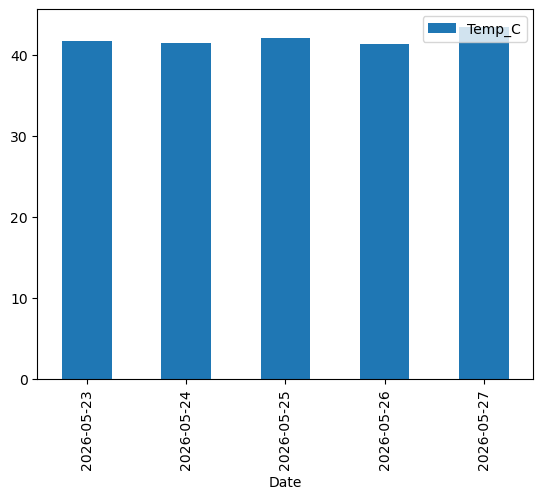

In [65]:
sdf = df[df['Time'].astype(str) == "12:00:00"]
print(sdf)
sdf.plot.bar(x='Date',y='Temp_C')